#  EDA

## IMPORTAR PAQUETES

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Automcompletar rápido
%config IPCompleter.greedy=True

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [23]:
ruta_proyecto = 'C:/Users/Lenovo/Documents/portafolio_ds/automation/LEAD_KAGGLE'

Nombres de los archivos de datos.

In [24]:
nombre_cat = 'cat_resultado_calidad.pickle'
nombre_num = 'num_resultado_calidad.pickle'

Cargar los datos.

In [25]:
cat = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_cat)
num = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_num)

## EDA CATEGÓRICAS

### Análisis estadístico

In [26]:
def frecuencias_cat(df_cat):
    resultado = df_cat.apply(lambda x: x.value_counts(normalize = True)).T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return(resultado)

In [27]:
pd.set_option('display.max_rows', None)

In [28]:
frecuencias_cat(cat)

,Variable,Valor,Frecuencia
84,a_free_copy_of_mastering_the_interview,Yes,0.315553
83,a_free_copy_of_mastering_the_interview,No,0.684447
78,asymmetrique_activity_index,03.Low,0.041280
76,asymmetrique_activity_index,01.High,0.090136
77,asymmetrique_activity_index,02.Medium,0.868584
81,asymmetrique_profile_index,03.Low,0.003865
79,asymmetrique_profile_index,01.High,0.236704
80,asymmetrique_profile_index,02.Medium,0.305504
82,asymmetrique_profile_index,Unknown,0.453927
70,city,OTHER,0.007576


In [29]:
pd.reset_option('display.max_rows')

Primero se eliminan los registros de personas que no quieren ser contactadas por email o llamada, una vez pasado ese filtro se elimina la varible (columna) y así nos quedamos únicamente con los registros de personas que sí quieren ser contactadas. Cuando este tipo de variables tienen 'Yes', quiere decir que la persona no quiere ser llamada, cuando tienen 'No' quiere decir que sí pueden ser llamadas.

Borrar las de cómo nos conociste porque tienen un conteo bajísimo, en 'how_did_you_hear_about_x_education' el 78% de los valores es 'Select', por tanto, estas variables sólo van a estar ocupando espacio en lugar de aportar información relevante y verídica.

In [30]:
cat = cat.loc[(cat.do_not_call !='Yes') & (cat.do_not_email !='Yes') & (cat.last_activity !='Email Bounced')] \
        .drop(columns = ['how_did_you_hear_about_x_education',
                         'lead_profile',
                         'newspaper_article',
                         'search',
                         'digital_advertisement',
                         'through_recommendations',
                         'what_matters_most_to_you_in_choosing_a_course',
                         'do_not_call',
                         'do_not_email',
                         'a_free_copy_of_mastering_the_interview'])

In [31]:
cat.shape

(5940, 11)

In [32]:
num.shape

(6468, 7)

In [33]:
#borrar los registros de num en base a lo que borramos en cat
num = num[num.index.isin(cat.index)]

In [34]:
num.shape

(5940, 7)

### Análisis gráfico

In [35]:
def graficos_eda_categoricos(cat):
    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)
        
    # Eliminamos los ejes vacíos en caso de que el número de variables sea impar
    for i in range(cada + 1, len(ax)):
        f.delaxes(ax[i])
        
    # Mostramos los gráficos
    plt.tight_layout()
    plt.show()

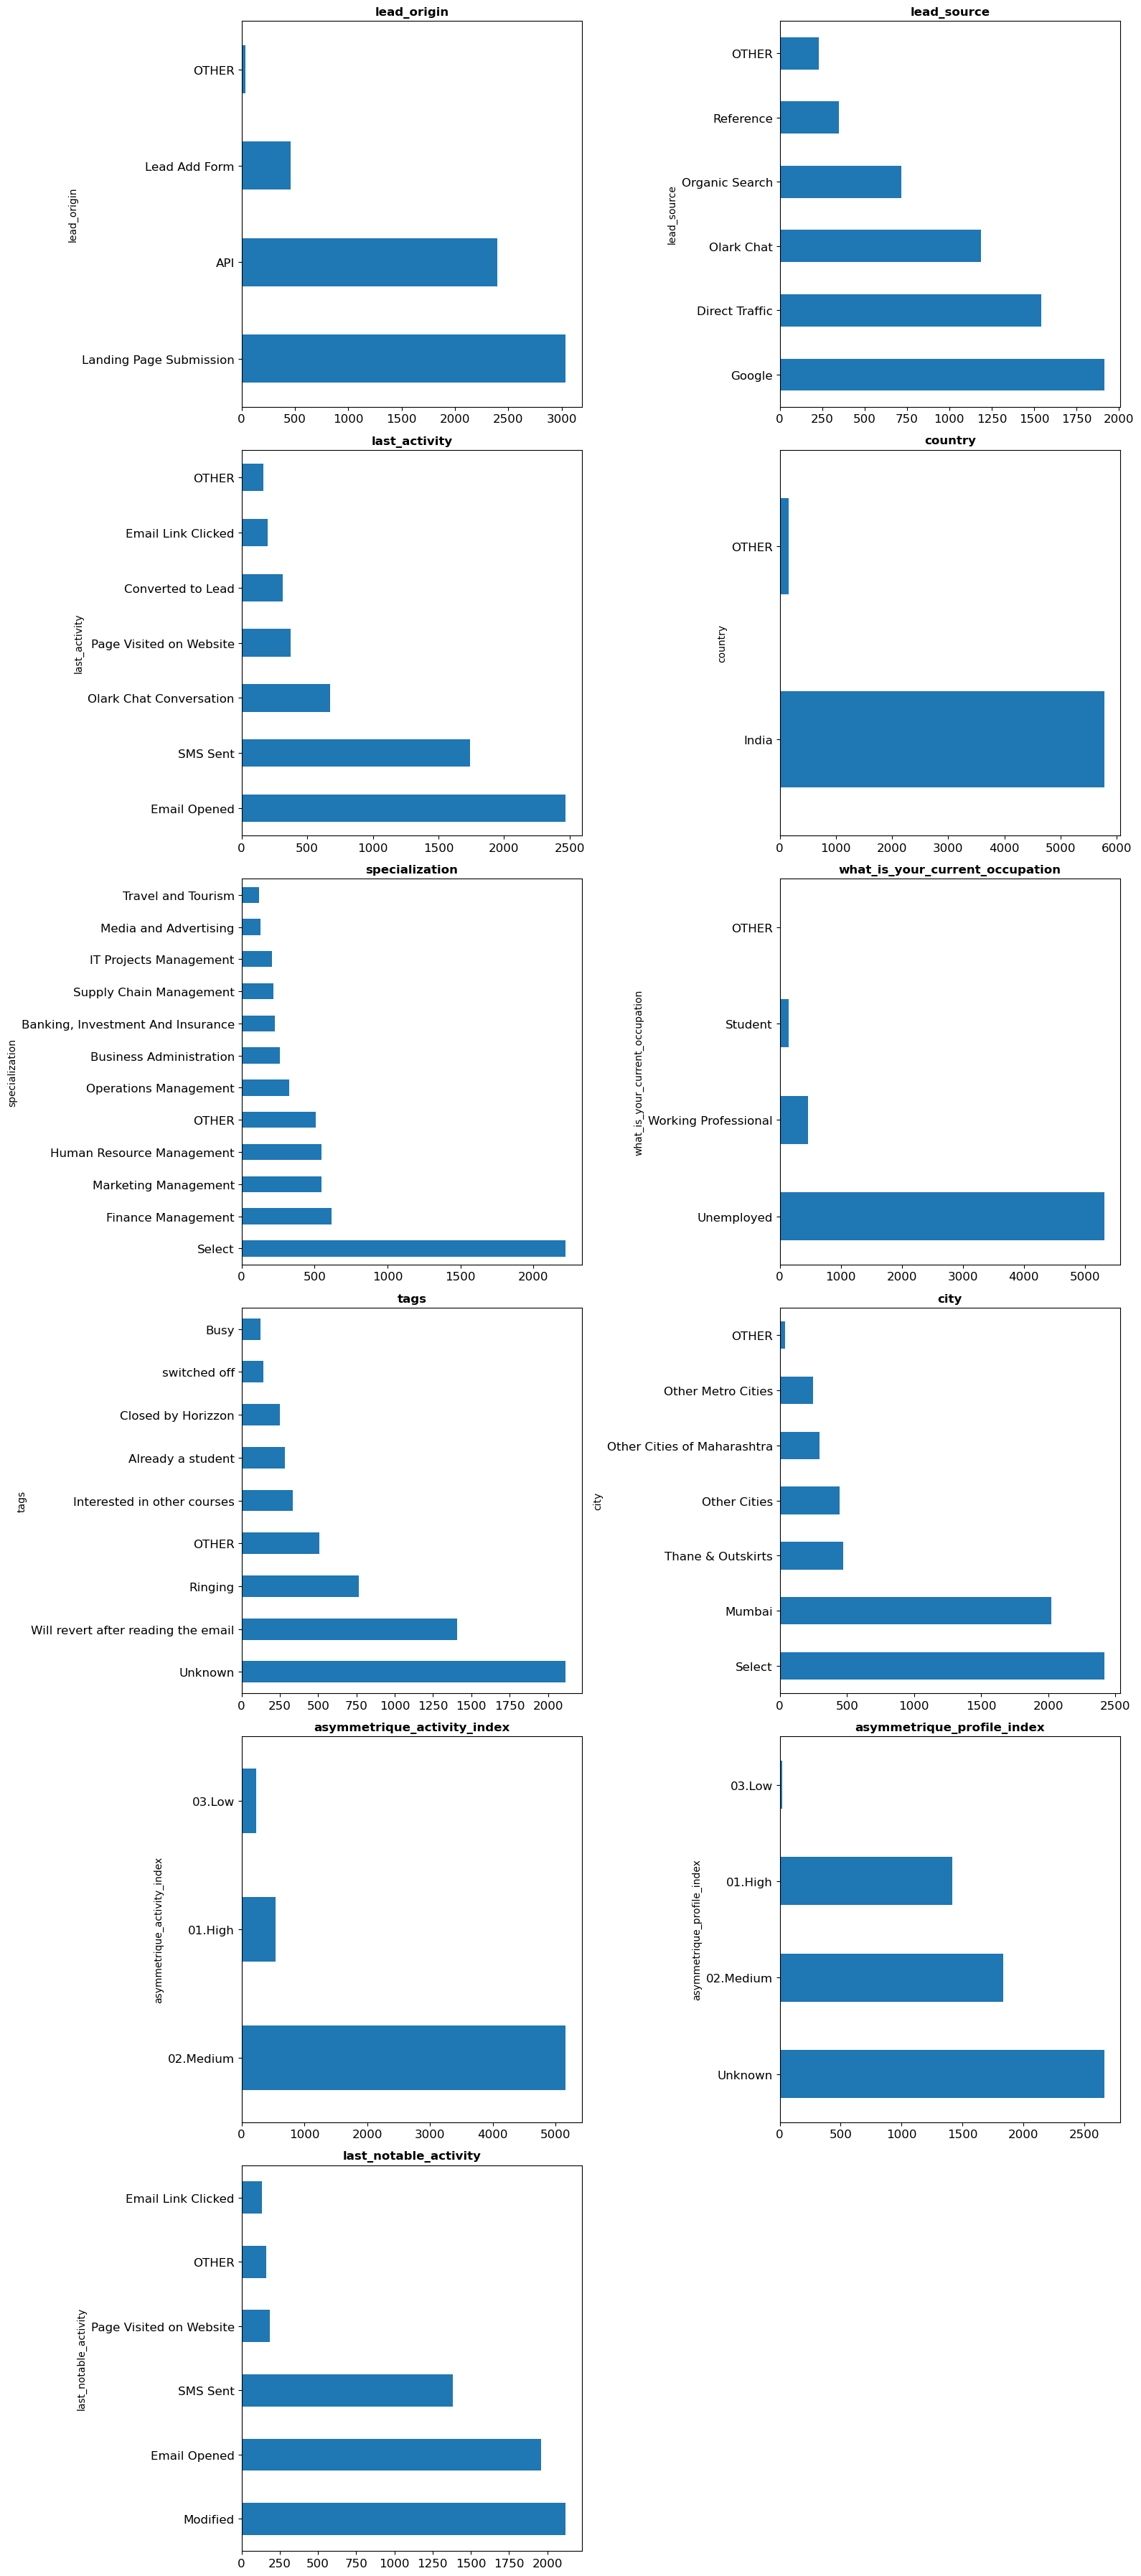

In [36]:
graficos_eda_categoricos(cat)

## EDA NUMÉRICAS

### Análisis estadístico

In [37]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [38]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
lead_number,5940.0,618124.994613,617329.5,23467.382111,579533.0,597263.25,617329.5,638539.25,660737.0
converted,5940.0,0.400505,0.0,0.490042,0.0,0.0,0.0,1.0,1.0
total_visits,5940.0,3.306566,3.0,3.351415,0.0,1.0,3.0,5.0,50.0
total_time_spent_on_website,5940.0,488.142593,247.0,549.643737,0.0,4.75,247.0,950.0,2272.0
page_views_per_visit,5940.0,2.318495,2.0,2.036892,0.0,1.0,2.0,3.0,20.0
asymmetrique_activity_score,5940.0,14.174411,14.0,1.039975,7.0,14.0,14.0,14.0,18.0
asymmetrique_profile_score,5940.0,16.18468,16.0,1.353524,11.0,16.0,16.0,16.0,20.0


### Análisis gráfico

In [39]:
def graficos_eda_continuas(num):
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)
        
    # Eliminamos los ejes vacíos en caso de que el número de variables sea impar
    for i in range(cada + 1, len(ax)):
        f.delaxes(ax[i])
        
    # Mostramos los gráficos
    plt.tight_layout()
    plt.show()

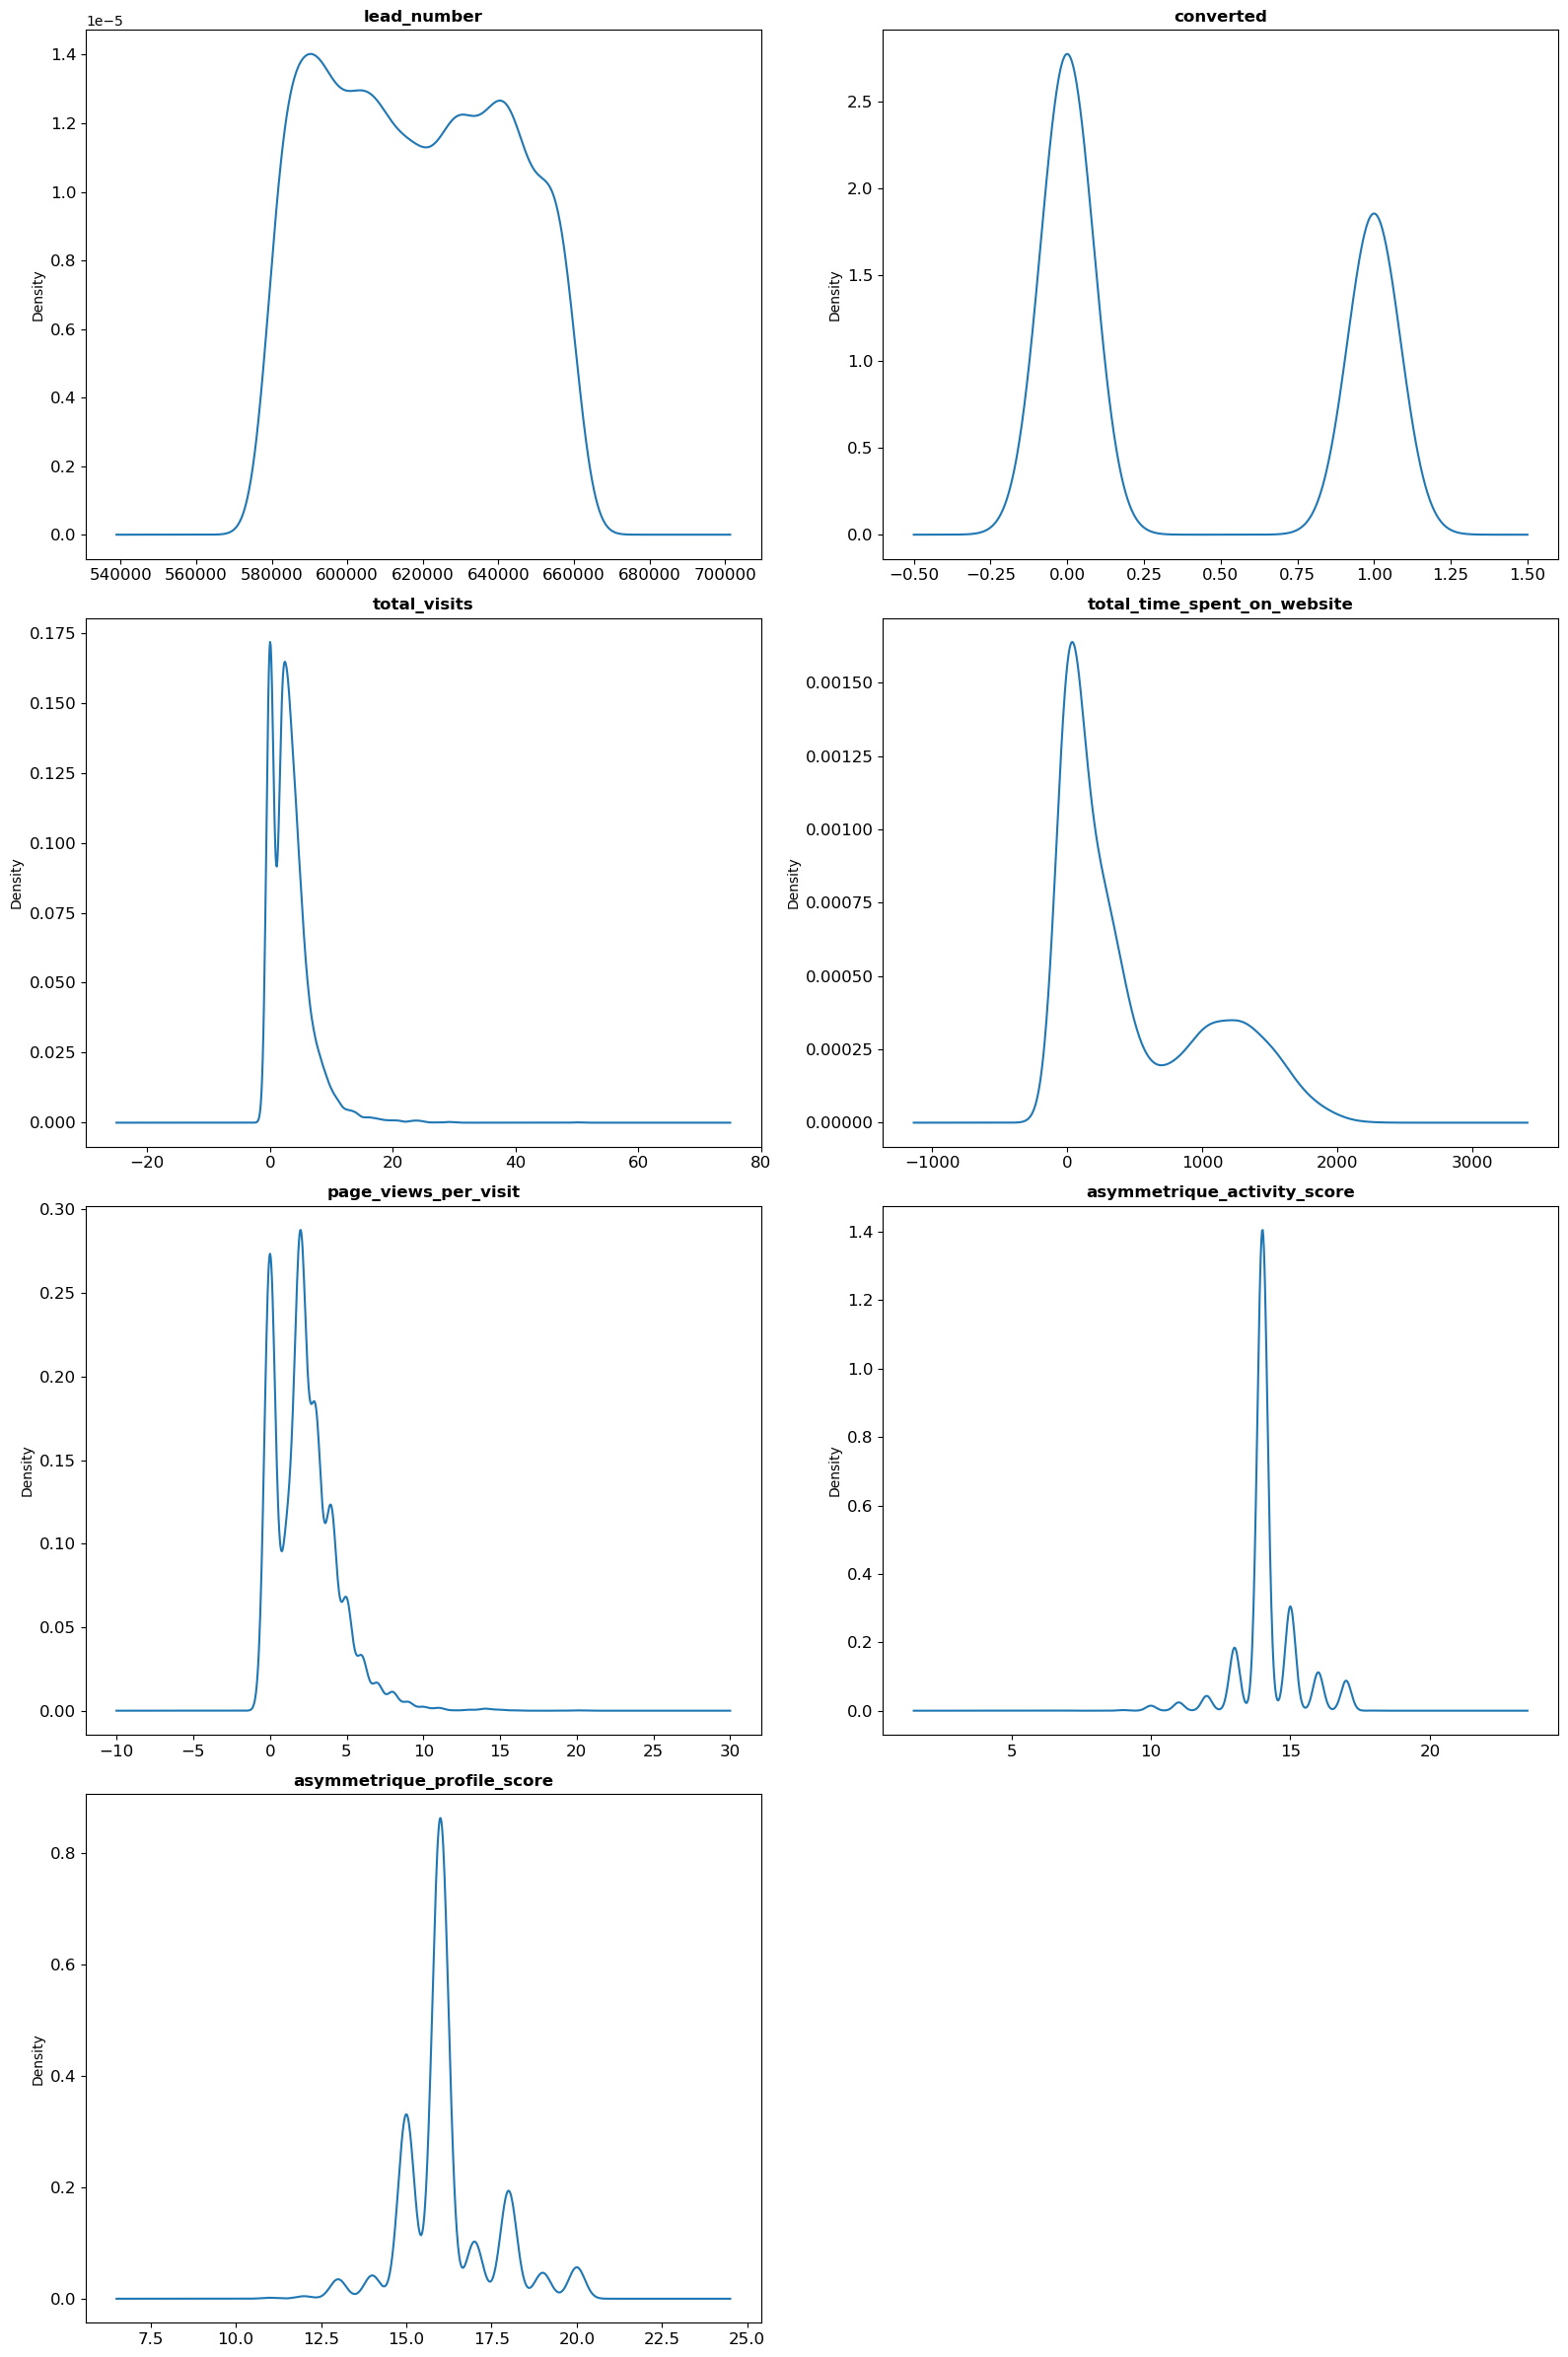

In [40]:
graficos_eda_continuas(num)

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

In [41]:
#Definir los nombres de los archivos
ruta_cat = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'cat_resultado_eda.pickle'
ruta_num = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'num_resultado_eda.pickle'

In [42]:
#Guardar los archivos
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)